# Concept: Burst Search

This notebook describes the organization and behavior of the `Bursts` table.

The cell below loads a test data set with which to deomonstrate the burst search behaviors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.cfuncs as smc # this is for calling C-optimized functions for internal calls

And generate the periods and background parameters that underly the burst search.

In [2]:
prds = smf.Param(smf.Periods, params={'period':30.0, 'detdef':smf.DetDef(2,2)})
bg = smf.Param(smf.BG, params={'func':smf.bg.exp_mlefit, 'tail_min':5e-4}, parents={'base':prds})

## Basic Burst Search

The `Bursts` table provides the basic burst search functionality.

### Burst Definition

Fundamentally a burst is a range of time $[t_{start}, t_{stop})$, which need not be the start/stop times of photons.

> **Note**
>
> The choice to use a half open interval in the above definition is chosen for programatic reasons,
> not for mathematical clarity.
> In most Python notation, half open intervals are used,
> thus in smfBursts, intervals are genarally expressed in half open intervals.

The `Bursts` table uses the `func` parameter to set the function that defines the start/stop times.
The most commonly used functions are the *mwindow* functions, which we will describe in the next sections.

### Sliding Window Burst Search Algorithm (*mwindow* functions)

The sliding window burst search algorithm uses the eponymous "sliding window" to compute a pseudo-instantaneous rate photon rate, 
and select the ranges in time where the instantaneous rate is above some multiple (can be fractional) of the background.

Consider the data as a set of photon arrival times 
$T = \{t_{0}, t_{1}, ... t_{N}\}$.

We define a sliding window of size $m$ as photons with indexes from $\{t_{i}, ... t_{i+m}\}$

Therefore there are $N-m$ sliding windows in $T$

The instantaneous photon rate of a sliding window of size $m$ and index $i$ is 

$^{m}\tau_{i} = \frac{m-1-c}{\Delta_{m}t_{i}} = \frac{m-1-c}{t_{i+m}- t_{i}}$

If $^{m}\tau_{i}$ is greater than the threshold, the photons $\{t_{i}, ... t_{i+m}\}$ are considered "in" a burst.

The threshold can be set in 2 ways: 

1. As a multiplier above the background rate (`func=smf.bursttables.burstsearch_mwindowF_bg`) (generally recomended):

   $^{m}\tau_{i} \ge F\tau_{bg}$

   Where $\tau_{bg}$ is the background rate, and $F$ is the constant multiplier.

2. As a likelihood that it is not from background, assuming a poisson process
   (`func=smf.bursttables.burstsearch_mwindowP_bg`) (discouraged):

   $^{m}\tau_{i} \geq Erlang_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})$

   Where $P$ is the likelihood threshold and $PPF$ indicates percent point function, the inverse of CDF.
   Note that $c$ in this definition is always $-1.0$ in this option
   as this is intrinsict to the assumption of Poisson background,
   and therefore the computation with the Erlang distribution

If a string of consecutive windows all satisfy the threshold, all photons in common can be considered as part of the single bursts.
Since consecutive windows already overlap, there is no chance of a "gap".

The *mwindow* functions define burst start/stop times by the theoretical "limit" of the sliding window.

Thus:

1. if the threshold is set by condition 1:

   $b_{start} = t_{i_{first}+m} - (F\tau_{bg})^{-1}$, and

   $b_{stop} = t_{i_{last}} + (F\tau_{bg})^{-1}$, or
2. if the threshold is set by condition 2:

   $b_{start} = t_{i_{first}+m} - \mathrm{Erlang}_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})^{-1}$, and

   $b_{stop} = t_{i_{last}} + \mathrm{Erlang}_{PPF}(P, k=m, \lambda = \tau_{bg}^{-1})^{-1}$

In the next section we will cover burst fusion. 
For now, know that setting `fuse=-1.0` indicates not to perform burst fusion.

So lets demonstrate option 1:

In [3]:
print(smf.Param(smf.Bursts, 
                params={
                    'func':smf.bursttables.burstsearch_mwindowF_bg,
                    'stream':smf.PhSel('0ex_1ex1em'), # streams to search over
                    'm':10, # (default) size of sliding window
                    'F':6.0, # factor to use in computing background threshold, should be > 1 if asP==True, <1 if asP==True
                    'c':-1.0, # rate correction factor, nearly always -1.0
                    'fuse':-1.0 # explained in the next section
                },
                parents={'bg':bg}).description)

Table: Bursts
Params:
  func: smfbursts.bursttables.burstsearch_mwindowF_bg
  stream: 0ex_1em
  m: 10
  F: 6.0
  c: -1.0
  fuse: -1.0
Parents:
  bg:
    Table: BG
    Params:
      compute_stream: single_all
      func: smfbursts.backgroundtables.exp_mlefit
      tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
      auto_threshold: False
    Parents:
      base:
        Table: Periods
        Params:
          period: 30.0
          start_at: time_min
          stop_at: over
          detdef: DetDef2ex2em


This demonstrates option 2:

In [4]:
print(smf.Param(smf.Bursts, 
                params={
                    'func':smf.bursttables.burstsearch_mwindowP_bg,
                    'stream':smf.PhSel('0ex_1ex1em'), # streams to search over
                    'm':10, # (default) size of sliding window
                    'P':0.95, # factor to use in computing background threshold, should be > 1 if asP==True, <1 if asP==True
                    'fuse':-1.0
                },
                parents={'bg':bg}).description)

Table: Bursts
Params:
  func: smfbursts.bursttables.burstsearch_mwindowP_bg
  stream: 0ex_1em
  m: 10
  P: 0.95
  fuse: -1.0
Parents:
  bg:
    Table: BG
    Params:
      compute_stream: single_all
      func: smfbursts.backgroundtables.exp_mlefit
      tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
      auto_threshold: False
    Parents:
      base:
        Table: Periods
        Params:
          period: 30.0
          start_at: time_min
          stop_at: over
          detdef: DetDef2ex2em


## Fusing bursts

Since the end of a burst is denoted by the $i+m$<sup>th</sup> photon while the beginning is demarkated by the $i$<sup>th</sup> photon,
it is possible for bursts to be overlapping.
Internally (ie called by `Bursts`), the sliding window burst search is performed by the `cfuncs.burstsearch()` function.
It requires the photon times, as well as detectors (and which detectors to search), and background count rates.
It returns the start and stop times of each burst.

`fuse` can be $-1.0$, $0.0$ or possitive.

When the `fuse` keyword is $-1.0$, there is the potential to get overlapping bursts:

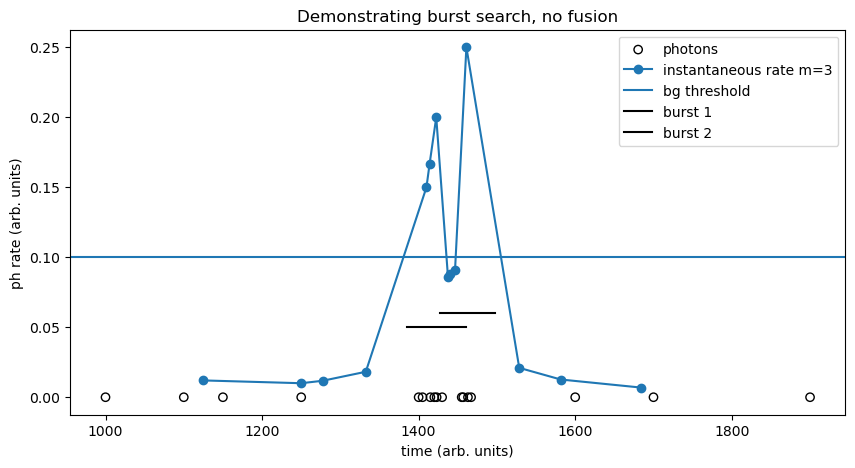

In [5]:
m = 3
F = 10.0
# "theoretical set of photon times"
photons = np.array([1000, 1100, 1150, 1250, 1400, 1405, 1415, 1420, 1423, 1430, 1455, 1457, 1463, 1467, 1600, 1700, 1900])
bgr = 1/100 # background separation is typically ~100
sw = photons[m:] - photons[:-m]
fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# code for performing burst search, first section just creates necessary context
periods = np.array([photons.min()-10, photons.max() + 10])
dets = np.zeros(photons.size, dtype=np.uint8) # detectors indexes
det_ids = np.array([0,], dtype=np.uint8) # detectors to treat as part of burst search
bgr = np.array([bgr,])
# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=-1.0)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating burst search, no fusion")
plt.legend()

However, when the `fuse` keyword is $0.0$, the search will automatically detect when
$b_{start, i+1} < b_{stop, i}$ and "fuse" the bursts 
so that $b^{\prime}_{start, j} = b_{start, i}$, and $b^{\prime}_{stop, j} = b_{stop, i+1}$

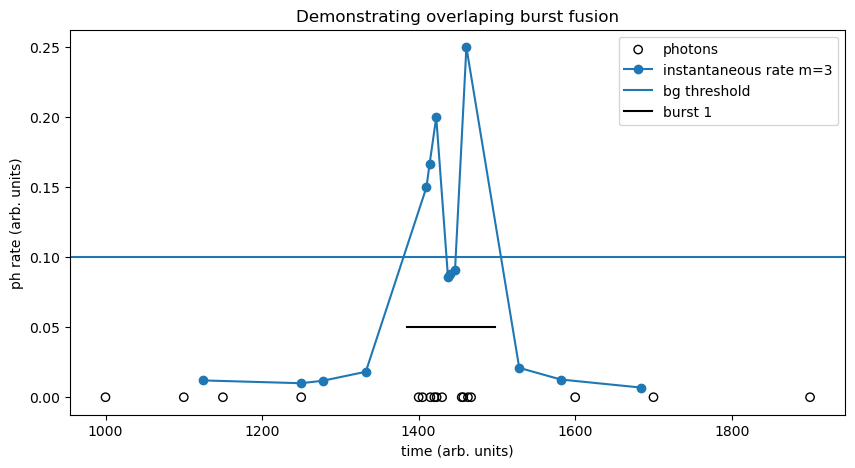

In [6]:
fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=0.0)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating overlaping burst fusion")
plt.legend()

It is the default to fuse bursts in this way, when creating a `Bursts` `Param`, 
ie the default value of 'fuse' is $0.0$:

In [7]:
burst_fuse = smf.Param(smf.Bursts, 
                       params={
                           'stream':smf.PhSel('0ex_1ex1em'),
                           'm':10,
                           'F':6.0,
                           'fuse':0.0
                       },
                       parents={'bg':bg})

burst_default = smf.Param(smf.Bursts, 
                          params={
                              'stream':smf.PhSel('0ex_1ex1em'),
                              'm':10,
                              'F':6.0,
                       },
                       parents={'bg':bg})

burst_fuse == burst_default

True

Fusing of bursts is also possible for closely spaced bursts (ie `fuse` is positive).
If $b_{stop, i} + t_{fuse} < b_{start, i+1}$ the the bursts are fused: 
$b^{\prime}_{start, j} = b_{start, i}, b^{\prime}_{stop, j} = b_{stop, i+1}$

Burst fusion can either be done during burst search, or on the output 
(arrays of starts and stops) of an existing burst search.

If the `fuse` argument of `cfuncs.burstsearch()` is positive, burst fusion takes place during burst search.
It does this by simply checking if, when it encounters a new burst, it is close enough to the previous
one to be "fused", if so, it will simply replace the stop time, intead of adding a new burst.

The function `cfuncs.fusebursts()` searches for "fusable" bursts, fusing them together.

The reason for the "double" implementation is that doing the fusion during the burst search
is faster, however, as we will see in the next section, we can create bursts not just from
a burst search, and so it is useful to have a standalone implementation.

> **Note**
>
> `cfuncs.burstsearch()` reads the `fuse` argument as float in units of seconds
> (ie it divides by clk_p and converts to integer to get the actual spacing to fuse bursts)
> whiel `cfuncs.fusebursts()` treats `fuse` as an integer, already in the units of timestamps

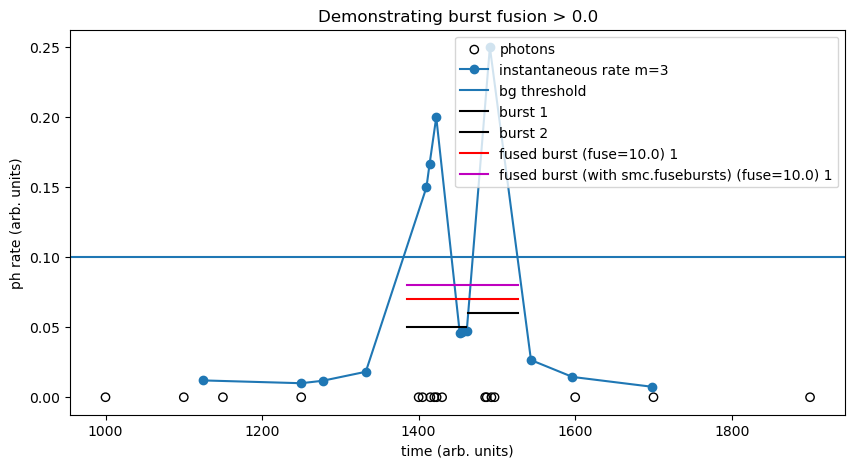

In [8]:
# "theoretical set of photon times"
m = 3
F = 10.0
photons = np.array([1000, 1100, 1150, 1250, 1400, 1405, 1415, 1420, 1423, 1430, 1485, 1487, 1493, 1497, 1600, 1700, 1900])
bgr = 1/100 # background separation is typically ~100
sw = photons[m:] - photons[:-m]

fig = plt.figure(figsize=(10,5))
plt.scatter(photons, np.zeros(photons.size), ec='k', c='none', label='photons', marker='o', )
plt.plot(photons[:-m]+sw/2, m/sw, marker='o', label=f'instantaneous rate m={m}')
plt.axhline(bgr*F, label='bg threshold')

# code for performing burst search, first section just creates necessary context
periods = np.array([photons.min()-10, photons.max() + 10])
dets = np.zeros(photons.size, dtype=np.uint8) # detectors indexes
det_ids = np.array([0,], dtype=np.uint8) # detectors to treat as part of burst search
bgr = np.array([bgr,])
# burst search function
starts, stops = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=0.0)
# plot burst ranges
for i, (pos, start, stop) in enumerate(zip(np.arange(0.05, starts.size, 0.01), starts, stops)):
    plt.plot([start, stop], [pos, pos], c='k', label=f'burst {i+1}')

fuse = 10.0
startsp, stopsp = smc.burstsearch(photons, dets, periods, bgr, 1.0, m=m, F=10.0, fuse=fuse)
for i, (pos, start, stop) in enumerate(zip(np.arange(0.01+pos, startsp.size, 0.01), startsp, stopsp)):
    plt.plot([start, stop], [pos, pos], c='r', label=f'fused burst (fuse={fuse}) {i+1}')

# show that fuse is the same with fusebursts
startspp, stopspp = smc.fusebursts(starts, stops, int(fuse))
for i, (pos, start, stop) in enumerate(zip(np.arange(0.01+pos, startspp.size, 0.01), startspp, stopspp)):
    plt.plot([start, stop], [pos, pos], c='m', label=f'fused burst (with smc.fusebursts) (fuse={fuse}) {i+1}')


plt.xlabel("time (arb. units)")
plt.ylabel("ph rate (arb. units)")
plt.title("Demonstrating burst fusion > 0.0")
plt.legend()

Positive values of `fuse` in `Bursts` `Param`s indicate the $t_{fuse}$ (in seconds) so a parameter to fuse bursts
with a separation of less than 1 ms would be:

In [9]:
burst_fuse1ms = smf.Param(smf.Bursts, 
                         params={
                             'm':10,
                             'F':6.0,
                             'stream':smf.PhSel('0ex_1ex1em'),
                             'fuse':1e-3
                         },
                         parents={'bg':bg})

### Change Point Burst Search

(Zhang and Yang 2005)[https://doi.org/10.1021/jp0546047] introduced a different burst search algorithm.

#### Change Point algorithm description

This was based on change point analysis, and requires knowledge of both
- background level $I_{BG}$
- brightness of bursts, $I_{1}$, expressed as the signal-to-background ratio, $I_{1} = sbr I_{BG}$

And seeks bursts based on when the probability that a given group of photons is signal,
with thresholds set by
- $\alpha$ likelihood burst is false positive (type-I error)
- $\beta$ likelihood burst is not a false negative (type-II error)

Therefore the smaller these numbers, the more stringent the threshold.

In the interal algorithm, the 4 input constants are used as follows:

We define the folowing:

$A = (1- \beta) / \alpha$

$B = \beta / (1 - \alpha)$

These are used to define functions and thresholds for photon windows of varying sizes.

We have:

$A(n) = n \frac{\ln(I_{1})-\ln(I_{BG})}{I_{1}-I_{BG}} - \frac{\ln(B)}{I_{1}-I_{BG}}$

$B(n) = n \frac{\ln(I_{1})-\ln(I_{BG})}{I_{1}-I_{BG}} - \frac{\ln(A)}{I_{1}-I_{BG}}$

and

$f(\Delta_{n}t) = n \ln(I_{1}-I_{BG}) - \frac{I_{1}-I_{BG}}{I_{BG}}\Delta_{n}t$

$ h = \ln(3) + 2\ln(\frac{I_{BG}-I_{1}}{I_{1}}+ \ln(I_{1}/I_{BG}) + 1) - \ln(-\alpha \ln(\alpha))$

These are used in two search algorithms, SPRT (sequential probability ratio test), and CUSUM.
These functions take a start point, and evaluate progressively larger $\Delta_{n}T$ 
(time difference between photons, $n$ indicating the number of photons in the window)
defined as follows:

$SPRT = \begin{cases} 
\Delta_{n}t \leq B(n) & \text{start new window} \\ 
B(n) \le \Delta_{n}t \le A(n) & \text{test}\:n+1 \\
\Delta_{n}t \geq A(n) & \text{end of burst found} 
\end{cases} $


$CUSUM = \begin{cases} 
f(\Delta_{n}t) \le 0 & \text{start new window} \\ 
f(\Delta_{n}t) \le h & \text{test}\:n+1\\
f(\Delta_{n}t) \geq h & \text{start of burst found}
\end{cases} $

where starting a new window indicates the "start" photon is now updated to the last photon in the evaluted previous window.

The basic loop is 

$\begin{matrix}f-CUSUM & \text{find start of next burst}\\ r-CUSUM & \text{find end of curent burst} \\ SPRT & \text{find point to start next f-CUSUM evaluation}\end{matrix}$

where $f-$ and $r-$ indicate the direction (forward, backward) of the search algorithm.

#### Change Point Functions

To make a `Bursts` based `Param` using the change point burst search

smfBursts implements the algorithm with two options

1. `smf.bursttables.burstsearch_changepoint_constantsbr` where the signal to background is a constant set by the parameter *sbr*.
   With this method, it is prefered to deterimine the sbr by some external means,
   and the background period should be long enough so that the entire measurement is encompased in a single period.
2. `smf.bursttables.burstsearch_changepoint_maxrate` where the singal to background is calculated per background period
   using the max_rate function, based on a sliding window of the size of the parameter *m*.


In [10]:
# 1 hour long measuremnt single bg period
# set period to time (in seconds) of your experiment
sprd = smf.Param(smf.Periods, 
                 params={'period':3600.0, 'detdef':smf.DetDef(2,2)})
# BG for single period period
sbg = smf.Param(smf.BG, params={'func':smf.bg.exp_mlefit, 'tail_min':5e-4}, 
                parents={'base':sprd})

# Constant SBR change point burst search param
cpc = smf.Param(smf.Bursts, 
                params={'func':smf.bursttables.burstsearch_changepoint_constantsbr, 
                        'stream':smf.PhSel('0ex_1ex1em'), 
                        'alpha':1e-4, 'beta':1e-2, 
                        'sbr':20.0}, # sbr ratio
                parents={'bg':sbg} # use single period bg param as parent
               )

In [11]:
# Max rate sbr style change point burst search param
cpc = smf.Param(smf.Bursts, 
                params={'func':smf.bursttables.burstsearch_changepoint_maxrate, 
                        'stream':smf.PhSel('0ex_1ex1em'), 
                        'alpha':1e-4, 'beta':1e-2, 
                        'm':30}, # sliding window size
                parents={'bg':bg} # use standard bg param as parent
               )

## Burst Gate

The [DCBS](https://doi.org/10.1021/jp063483n) algorithm presented the idea of an "and" gate between two burst searches.

The idea is to take the intersection of two burst searches,
ie the only times in bursts are those where both burst searches "in burst".


To create such an and gate, we use the `BurstOvlp` table (short for burstoverlap).

This table has

2 params: 
- `fuse` : a float
- `truthtable` : explained in the following sections, either a string identifying the type of gate,
   or a boolean numpy array truthtable, functions very similar to how the truthtable of a `GateGroup`
  functions (see [GatesTutorial](GatesTutorial.ipynb#GateGroup-Composition))

and 1 parent: 
- `bases`

To replicate DCBS, we need `Bursts` `Param`s for a bursts search on the
donor excitaiton streams, and another on the acceptor excitation stream.
We supply these as the `bases` parents, and set `truthtable='and'`.
After the bursts are gated, if `fuse` positive (if 0, the fuse step is skipped),
then the gated bursts will be fused with `cfuncs.fusebursts()`, as discussed earlier.
Note that `fuse` is the separation in seconds.

In [12]:
# create burst searches otherwise identical, but with different streams
bases = [smf.Param(smf.Bursts, 
                   {'stream':stream, 'm':10, 'F':6.0}, {'bg':bg}) 
         for stream in (smf.PhSel('0ex'), smf.PhSel('1ex1em'))]
# create BurstOvlp Param
bursts_dcbs = smf.Param(smf.BurstOvlp,
                        params={
                            'truthtable':'and', # and gate 
                            'fuse':0.0 # do not fuse
                        },
                       parents={'bases':bases}) # Dex/AexAem burst searches
tt = bursts_dcbs.params['truthtable']
tt

array([[False, False],
       [False,  True]])

This truthtable is that of a classical "AND" gate.
Performing the AND gate is done internally (that is by the `Busrts` class) by the function `cfuncs.burstgate()`.

It's function is demonstrated below

Text(0.5, 1.0, 'Demonstration of burst AND gate')

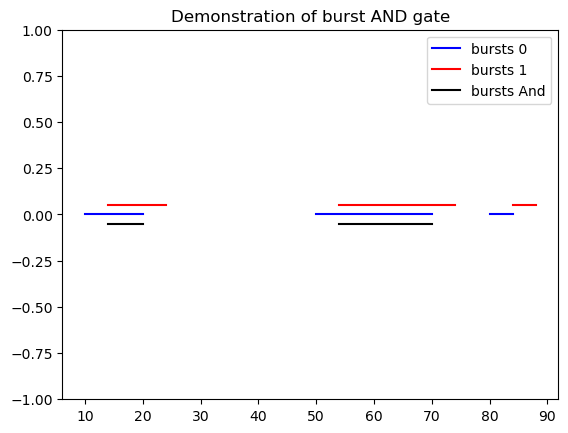

In [13]:
starts0, stops0 = np.array([[10, 50, 80], 
                            [20, 70, 84]])
setl = True
for start, stop in zip(starts0, stops0):
    if setl:
        plt.plot([start, stop], [0, 0], c='b', label='bursts 0')
        setl = False
    else:
        plt.plot([start, stop], [0, 0], c='b')

starts1, stops1 = starts0 + 4, stops0 + 4

setl = True
for start, stop in zip(starts1, stops1):
    if setl:
        plt.plot([start, stop], [0.05, 0.05], c='r', label='bursts 1')
        setl = False
    else:
        plt.plot([start, stop], [0.05, 0.05], c='r')

# internal call to perform and gate:
startsA, stopsA = smc.burstgate([starts0, starts1], [stops0, stops1], tt)

setl = True
for start, stop in zip(startsA, stopsA):
    if setl:
        plt.plot([start, stop], [-0.05, -0.05], c='k', label='bursts And')
        setl = False
    else:
        plt.plot([start, stop], [-0.05, -0.05], c='k')

plt.ylim([-1.0, 1.0])
plt.legend()
plt.title("Demonstration of burst AND gate")

Note the last argument to `cfuncs.burstgate()`.
This is the truthtable for the AND operator, which behaves in a way analagous to the truthtable of `Gates`, 
see the documentation on [gates](GatesTutorial.ipynb).

This means that it is possible to for instance use an OR gate instead to take all time ranges
encompased by both:

Text(0.5, 1.0, 'Demonstration of burst OR gate')

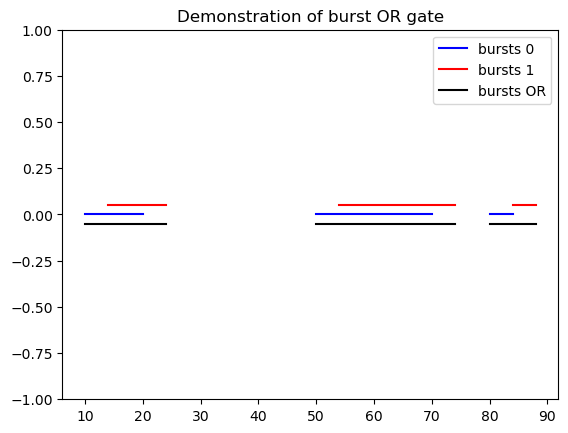

In [14]:
ttOR = np.array([[False, True],[True, True]])

setl = True
for start, stop in zip(starts0, stops0):
    if setl:
        plt.plot([start, stop], [0, 0], c='b', label='bursts 0')
        setl = False
    else:
        plt.plot([start, stop], [0, 0], c='b')

setl = True
for start, stop in zip(starts1, stops1):
    if setl:
        plt.plot([start, stop], [0.05, 0.05], c='r', label='bursts 1')
        setl = False
    else:
        plt.plot([start, stop], [0.05, 0.05], c='r')



startsA, stopsA = smc.burstgate([starts0, starts1], [stops0, stops1], ttOR)

setl = True
for start, stop in zip(startsA, stopsA):
    if setl:
        plt.plot([start, stop], [-0.05, -0.05], c='k', label='bursts OR')
        setl = False
    else:
        plt.plot([start, stop], [-0.05, -0.05], c='k')

plt.ylim([-1.0, 1.0])
plt.legend()
plt.title("Demonstration of burst OR gate")

We can create a `BurstOvlp` based `Param` with an OR gate in the following way:

In [15]:
bursts_ORbs = smf.Param(smf.BurstOvlp,
                        params={
                            'fuse':0.0,
                            'truthtable':'or'
                        },
                       parents={'bases':bases})
ttOR = bursts_ORbs.params['truthtable']
ttOR

array([[False,  True],
       [ True,  True]])

Note that we can specify the truthtable as a (2x...) array as well.
Specifying a string is provided to make creating the and/or gates more convenient.

But, by specifying as an array, other logical operations are possible.

In [16]:
bursts_ORtt = smf.Param(smf.BurstOvlp,
                        params={
                            'fuse':0.0,
                            'truthtable':np.array([[False, True],[True,True]])
                        },
                       parents={'bases':bases})
bursts_ORtt == bursts_ORbs

True

In [17]:
bursts_ANDtt = smf.Param(smf.BurstOvlp,
                         params={
                             'fuse':0.0,
                             'truthtable':np.array([[False, False],[False,True]])
                         },
                        parents={'bases':bases})
bursts_ANDtt == bursts_dcbs

True

### 3 or more streams

In the case of standard ALEX/PIE measuremnts, there is rarely a need to go beyond 2 streams,
however, especially for MFD and multi-spectral measurements, burst gating is not restricted to just 1 or 2 burst searches.

Note that the dimensionality of the truthtable grows with the number of burst searches, but every dimension is always size 2:

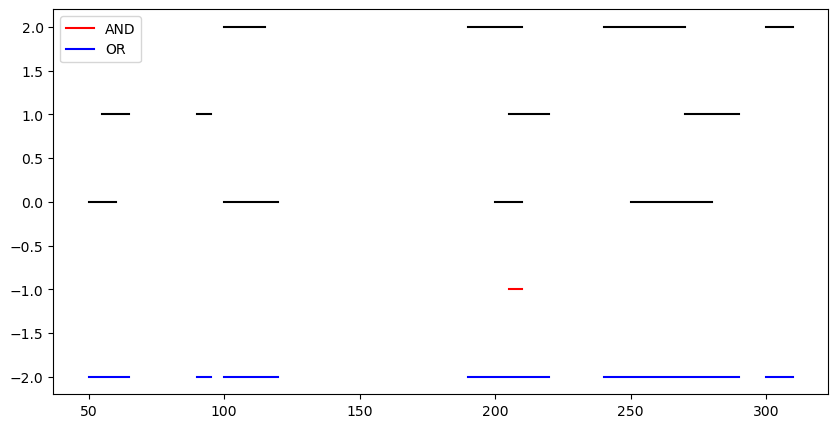

In [18]:
starts0 = np.array([ 50, 100, 200, 250])
stops0  = np.array([ 60, 120, 210, 280])

starts1 = np.array([ 55,  90, 205, 270])
stops1  = np.array([ 65,  95, 220, 290])

starts2 = np.array([100, 190, 240, 300])
stops2  = np.array([115, 210, 270, 310])

plt.figure(figsize=(10,5))
for i, (starts, stops) in enumerate(zip((starts0, starts1, starts2), (stops0, stops1, stops2))):
    for startstop in zip(starts, stops):
        plt.plot(startstop, [i, i], c='k')

# AND gate
startA, stopA = smc.burstgate([starts0, starts1, starts2], [stops0, stops1, stops2], np.array([[[False, False],[False, False]],[[False, False],[False, True]]]))
setl = True
for startstop in zip(startA, stopA):
    if setl:
        plt.plot(startstop, [-1, -1], c='r', label='AND')
        setl = False
    else:
        plt.plot(startstop, [-1, -1], c='r')

# OR gate
startA, stopA = smc.burstgate([starts0, starts1, starts2], [stops0, stops1, stops2], np.array([[[False, True],[True, True]],[[True, True],[True, True]]]))
setl = True
for startstop in zip(startA, stopA):
    if setl:
        plt.plot(startstop, [-2, -2], c='b', label='OR')
        setl = False
    else:
        plt.plot(startstop, [-2, -2], c='b')

plt.legend()

When creating `BurstOvlp` based `Params` with 3 or more burst searches,
the 'and' and 'or' strings still work as arguments to `truthtable`.

'and' will create an "all-and" type truthtable, 
ie only when all burst searches are in a burst will the output be in a burst,
that is the truthtable will be all False except for the "all true" position.

Likewise 'or' will create an "all-or" type truthtable,
where all elements are true except the all false position,
so if a time is in any of the burst searches, it is in the output.

In [19]:
burstsDA = smf.Param(smf.Bursts,
                          params = {
                              'stream':smf.PhSel('0ex1em'),
                              'm':10, 'F':5.0,
                          },
                         parents={'bg':bg})
bases3 = bases+[burstsDA,]

burst_search3all = smf.Param(smf.BurstOvlp,
                             params={
                                 'truthtable':'and'
                             },
                             parents={'bases':bases3})

burst_search3alltt = smf.Param(smf.BurstOvlp,
                               params={
                                   'truthtable':np.array([[[False,False],[False,False]],
                                                         [[False,False],[False,True]]])
                               },
                               parents={'bases':bases3})
burst_search3all == burst_search3alltt, burst_search3all.params['truthtable']

(True,
 array([[[False, False],
         [False, False]],
 
        [[False, False],
         [False,  True]]]))

In [20]:
burst_search3all = smf.Param(smf.BurstOvlp,
                             params={
                                 'truthtable':'or'
                             },
                             parents={'bases':bases3})

burst_search3alltt = smf.Param(smf.BurstOvlp,
                               params={
                                   'truthtable':np.array([[[False,True],[True,True]],
                                                         [[True,True],[True,True]]])
                               },
                               parents={'bases':bases3})
burst_search3all == burst_search3alltt, burst_search3all.params['truthtable']

(True,
 array([[[False,  True],
         [ True,  True]],
 
        [[ True,  True],
         [ True,  True]]]))

### Inverted gates

A final feature of the truthtable is the ability to invert a burst search.

That is, take the time ranges in between bursts, simply by maketing the truthtable `[True, False]`:

Let's demonstrate this with our line plots:

(-1.0, 1.0)

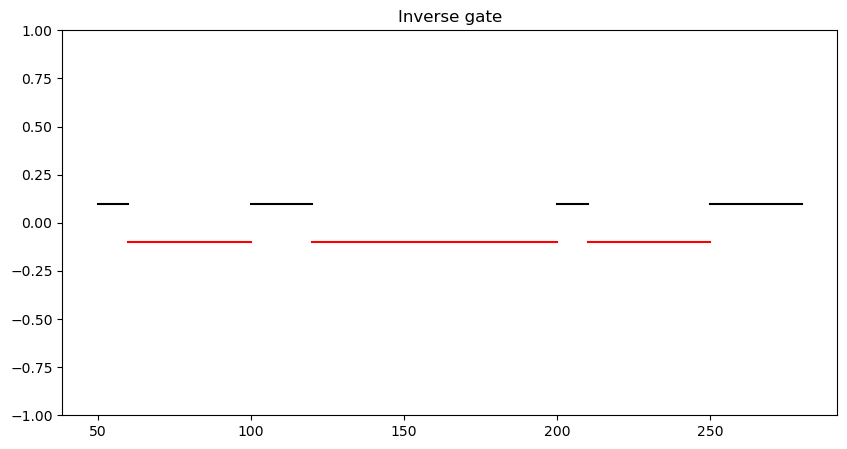

In [21]:
plt.figure(figsize=(10,5))
for startstop in zip(starts0, stops0):
    plt.plot(startstop, [0.1, 0.1], c='k')

startsI, stopsI = smc.burstgate([starts0,], [stops0,], np.array([True, False]))

for startstop in zip(startsI, stopsI):
    plt.plot(startstop, [-0.1, -0.1], c='r')

plt.title("Inverse gate")
plt.ylim([-1,1])

Creating inverted params, we can do this for a single gate, either by specifying the truthtable.

> **Note**
>
> 'inv' only works when there is a single burst search, see next for inverted gates generally

In [22]:
# Specify invert with a boolean truthtable
burst_INVtt = smf.Param(smf.BurstOvlp, 
                        params={
                            'truthtable':np.array([True, False])},
                        parents={'bases':bases[0]})
# invert string specification
burst_INV = smf.Param(smf.BurstOvlp, 
                      params={
                          'truthtable':'inv'},
                      parents={'bases':bases[0]})
burst_INV == burst_INVtt, burst_INV.params['truthtable']

(True, array([ True, False]))

By appending 'inv' before 'and' or 'or' strings, we can also create inverted and/or gates 
(truttables are simply the negation of the normal truthtable)
So 'invand' will create a search where it is always in a burst unless all burstsearches are in a burst,
and similarly, 'invor' will only be in a burst when all burst searches are not in a burst.

In [23]:
burst_INVAND = smf.Param(smf.BurstOvlp,
                         params={'truthtable':'invand'},
                         parents={'bases':bases})
burst_INVAND.params['truthtable']

array([[ True,  True],
       [ True, False]])

In [24]:
burst_INVOR = smf.Param(smf.BurstOvlp,
                        params={'truthtable':'invor'},
                        parents={'bases':bases})
burst_INVOR.params['truthtable']

array([[ True, False],
       [False, False]])

In [25]:
burst_INVOR = smf.Param(smf.BurstOvlp,
                        params={'truthtable':'invor'},
                        parents={'bases':bases})
burst_INVOR.params['truthtable']

array([[ True, False],
       [False, False]])

This is the end of the burst search tutorial.